Volcanic Potential: OTOC & Quantum Chaos Analysis

Objective: This notebook analyzes the Out-of-Time-Order Correlator (OTOC) for a particle in a "Volcano" potential ($V(x) \sim \cosh^{2\nu} + \text{sech}^2$). It compares the quantum scrambling rate against classical and semi-classical Lyapunov exponents to identify regions of local instability vs. global confinement.

How to use: Adjust parameters in the Configuration cell below. Run all cells to generate the Time-Evolution and Quantum-Classical Correspondence plots.

Imports and Configurations

In [29]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.optimize import newton


# --- USER CONFIGURATION ---

# 1. Potential Parameters
# NOTE: For nu > 0 (Confining), a1 MUST be negative to ensure Hermiticity (Hard Walls).
#a1 = -120
a1 = -0.05      
a2 = 120       # Depth of the central well
nu = 2.0         # Steepness of the confining walls

# 2. Grid Parameters
L = 10.0         # Spatial extent [-L, L]
N = 1000         # Grid resolution 

# 3. Simulation Parameters
mass = 1.0
t_max = 20   # Total simulation time
n_states_sim = 60 # Number of eigenstates to simulate OTOC for (0 to n)

# 4. Analysis & Plotting
limit_n_plot = 30      
fit_window = (0.5, 25.0) 

print(f"System Configured:\nGrid: [-{L}, {L}] ({N} pts)\nPotential: a1={a1}, a2={a2}, nu={nu}")

System Configured:
Grid: [-10.0, 10.0] (1000 pts)
Potential: a1=-0.05, a2=120, nu=2.0


Math functions

In [30]:
def sech(x):
    return 1.0 / np.cosh(x)

def build_Grid(L, N):
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]
    return x, dx

def volcano_potential(x, a1, a2, nu):
    """Returns V(x) for the Hamiltonian construction."""
    cosh_term = np.cosh(x)
    sech_term = sech(x)
    return -1 * ((a1 * (cosh_term)**(2 * nu)) + (a2 * (sech_term)**2))

def volcano_derivatives(x, a1, a2, nu):
    """
    Returns V, V', and V'' for Sensitivity Analysis.
    """
    cosh_x = np.cosh(x)
    sinh_x = np.sinh(x)
    tanh_x = sinh_x / cosh_x
    sech_x = 1 / cosh_x

    # Potential V
    V = -1 * ((a1 * (cosh_x)**(2 * nu)) + (a2 * (sech_x)**2))

    # First Derivative V'
    dV1 = a1 * (2 * nu) * (cosh_x ** (2 * nu - 1)) * sinh_x
    dV2 = a2 * (-2) * (sech_x ** 2) * tanh_x
    V_prime = -(dV1 + dV2)

    # Second Derivative V''
    d2V1 = 2 * nu * a1 * ((2 * nu - 1) * (cosh_x**(2 * nu - 2))*(sinh_x**2) + cosh_x**(2*nu))
    d2V2 = -2*a2 * (sech_x**2) * (-2 * (tanh_x**2) + (sech_x**2))
    V_double_prime = -(d2V1 + d2V2)

    return V, V_prime, V_double_prime

Hamiltonian Solver (DVR)

In [31]:
def solve_schrodinger(x, dx, V_array):
    """Diagonalizes the Hamiltonian using Finite Difference method."""
    size = len(x)
    array = np.ones(size)
    array_off = np.ones(size - 1)
    
    V_matrice = np.diag(V_array)
    # Kinetic Energy Matrix (Finite Difference)
    T_matrice = (2*np.diag(array, k=0) - np.diag(array_off, k=1) - np.diag(array_off, k=-1)) / (2 * dx * dx)
    H_matrice = T_matrice + V_matrice
    
    eigenvalue, eigenvector = np.linalg.eigh(H_matrice)
    return eigenvalue, eigenvector

def energy_matrices(x, dx, nu):
    """Builds Position and Momentum operators in the Energy Basis."""
    V_array = volcano_potential(x, a1, a2, nu)
    
    # 1. Position Operator (Position Basis)
    x_pos_matrice = np.diag(x)
    
    # 2. Momentum Operator (Position Basis)
    size = len(x)
    array_off = np.ones(size - 1)
    P_pos_matrice = -1j * (np.diag(array_off, k=1) - np.diag(array_off, k=-1)) / (2 * dx)
    
    # 3. Diagonalize
    eigenvalue, eigenvector = solve_schrodinger(x, dx, V_array)

    # 4. Transform Operators to Energy Basis
    x_matrice = eigenvector.T @ x_pos_matrice @ eigenvector
    p_matrice = eigenvector.T @ P_pos_matrice @ eigenvector

    return x_matrice, p_matrice, eigenvalue

OTOC Simulation Logic

In [32]:
def run_simulation_fast(N, t_max, n_state, nu):
    """
    Ultra-fast OTOC simulation using fully vectorized Matrix-Matrix multiplication.
    Eliminates the Python time-loop entirely.
    """
    # 1. Build Grid and Basis (Same as before)
    x, dx = build_Grid(L, N)
    x_E, p_E, energies = energy_matrices(x, dx, nu) 
    
    # 2. Setup Time Evolution Arrays
   
    t_range = np.linspace(0, t_max, 300)
    
  
    p_n = p_E[:, n_state] # Vector shape (N,)
    x_n = x_E[:, n_state] # Vector shape (N,)
    
    # 4. Vectorized Heisenberg Evolution

    E_t = energies[:, None] * t_range[None, :]
    

    phase_minus = np.exp(-1j * E_t) # Shape (N, T)
    phase_plus  = np.exp(1j * E_t)  # Shape (N, T)
    
    # --- Term 1: X(t) P |n> ---
   
    v1 = p_n[:, None] * phase_minus  # Shape (N, T)
    
    # Matrix-Matrix Multiplication: X @ v1
    
    y1 = x_E @ v1  # Shape (N, T)
    
   
    term1 = y1 * phase_plus # Shape (N, T)
    
    # --- Term 2: P X(t) |n> ---
   
    v2 = x_n[:, None] * phase_plus # Shape (N, T)
    
   
    y2 = p_E @ v2 # Shape (N, T)
    
    # Apply outer phase exp(-i E_n t) 
    phase_n = np.exp(-1j * energies[n_state] * t_range)
    term2 = y2 * phase_n[None, :] # Shape (N, T)
    
    # 5. Compute OTOC Intensity
 
    comm_matrix = term1 - term2
    
    # Sum of modulus squared down the column (spatial basis) for each time step
    otoc_values = np.sum(np.abs(comm_matrix)**2, axis=0)

    return otoc_values

def get_otoc_growth_rates(time_array, otoc_data_list, fit_window=None):
    """
    Calculates the MAXIMUM instantaneous growth rate (d/dt log(C)).
    Captures the transient burst of instability.
    """
    rates = []
    dt = time_array[1] - time_array[0]
    window_size = 3 
    
    print(f"Extracting MAX instantaneous growth rates from {len(otoc_data_list)} states...")
    
    for otoc_series in otoc_data_list:
        # Clean Data
        y_clean = np.maximum(np.array(otoc_series), 1e-15)
        log_y = np.log(y_clean)
        
        # Derivative d(ln C)/dt
        d_log_dt = np.gradient(log_y, dt)
        
        # Smoothing
        smoothed_rate = np.convolve(d_log_dt, np.ones(window_size)/window_size, mode='valid')
        
        # Find Max Rate in early time (first 50 units)
        search_limit_idx = np.searchsorted(time_array, 50.0) 
        if len(smoothed_rate) > search_limit_idx:
             max_rate = np.max(smoothed_rate[:search_limit_idx])
        else:
             max_rate = np.max(smoothed_rate)
        
        # Filter numerical noise
        if np.max(y_clean) < 1e-5:
            rates.append(0.0)
        else:
            rates.append(max(0, max_rate))
        
        """
        # Calculate the baseline initial value (mean of first few points)
        initial_val = np.mean(y_clean[:5])
        max_val = np.max(y_clean)
        
        if max_val < (5.0 * initial_val) or max_val < 1.0:
            rates.append(0.0)
        else:
            rates.append(max(0, max_rate))
        """
            
    return np.array(rates)

## Robust Sensitivity Analysis
Uses brentq (bracketing method) as primary root-finder for maximum reliability across all nu values.

In [33]:
# ===== ANALYTICAL POTENTIAL FUNCTIONS =====

def V_analytical(r, a1, a2, nu):
    """Analytical volcano potential: V(r) = -(a1 * cosh^(2nu) + a2 * sech^2)"""
    return -(a1 * np.cosh(r)**(2*nu) + a2 * (1/np.cosh(r))**2)

def dV1_analytical(r, a1, a2, nu):
    """First derivative V'(r)"""
    term1 = 2 * nu * a1 * (np.cosh(r)**(2*nu - 1)) * np.sinh(r)
    term2 = -2 * a2 * (1/np.cosh(r))**2 * np.tanh(r)
    return -(term1 + term2)

def dV2_analytical(r, a1, a2, nu):
    """Second derivative V''(r)"""
    term1_prime = 2*nu*a1 * ( (2*nu*np.cosh(r)**(2*nu) - (2*nu-1)*np.cosh(r)**(2*nu-2)) ) 
    term2_prime = 2*a2 * ( 3*(1/np.cosh(r))**4 - 2*(1/np.cosh(r))**2 )
    return -(term1_prime) + term2_prime

# Legacy compatibility (for older code that uses global parameters)
def dV1(x):
    """First derivative using global parameters a1, a2, nu"""
    return dV1_analytical(x, a1, a2, nu)

def dV2(x):
    """Second derivative using global parameters a1, a2, nu"""
    return dV2_analytical(x, a1, a2, nu)

In [34]:
# ===== ROBUST ROOT FINDING WITH BRENTQ =====

def find_turning_point_brentq(energy, a1, a2, nu, verbose=False):
    """
    Find classical turning point where V(r) = E using Brent's method.
    
    """
    
    def objective(r):
        """Function whose root we seek: V(r) - E = 0"""
        return V_analytical(r, a1, a2, nu) - energy
    

    if nu == 0:
        V_inf = -a1  
    elif nu < 0:
        V_inf = 0.0  
    else:  # nu > 0
        V_inf = np.inf  
    
  
    if not np.isinf(V_inf) and energy >= V_inf:
        if verbose:
            print(f"  Unbound state: E={energy:.4f} >= V_inf={V_inf:.4f}")
        return None
    
   
    r_min = 0.01  
    
    
    if nu <= 0 and not np.isinf(V_inf):
        energy_gap = abs(energy - V_inf)
        if energy_gap < 0.0001:
            r_max = 150.0  # Very close to continuum
        elif energy_gap < 0.001:
            r_max = 100.0
        elif energy_gap < 0.01:
            r_max = 50.0
        elif energy_gap < 0.1:
            r_max = 30.0
        elif energy_gap < 1.0:
            r_max = 20.0
        else:
            r_max = 15.0
    else:
        r_max = 15.0  # Default for nu > 0
    
 
    r_left = r_min
    r_right = 0.5  
    
    max_attempts = 30
    for attempt in range(max_attempts):
        try:
            y_left = objective(r_left)
            y_right = objective(r_right)
            
           
            if y_left * y_right < 0:
                # Use brentq - guaranteed to converge within bracket
                r_c = brentq(objective, r_left, r_right, xtol=1e-10, maxiter=100)
                
              
                residual = abs(objective(r_c))
                if residual < 1e-6:
                    if verbose:
                        print(f"  ✓ Found r_c = {r_c:.6f} (bracket: [{r_left:.3f}, {r_right:.3f}], residual: {residual:.2e})")
                    return r_c
            
           
            r_right = min(r_right * 1.8, r_max)
            
          
            if r_right >= r_max:
                break
                
        except Exception as e:
            if verbose:
                print(f"  Exception at attempt {attempt}: {e}")
            r_right = min(r_right * 1.8, r_max)
            continue
    
  
    try:
        y_left = objective(r_min)
        y_right = objective(r_max)
        
        if y_left * y_right < 0:
            r_c = brentq(objective, r_min, r_max, xtol=1e-10, maxiter=100)
            residual = abs(objective(r_c))
            if residual < 1e-6:
                if verbose:
                    print(f"  ✓ Found r_c = {r_c:.6f} (full range [{r_min:.3f}, {r_max:.3f}])")
                return r_c
    except Exception as e:
        if verbose:
            print(f"  Final attempt failed: {e}")
    
    # Could not find turning point
    if verbose:
        print(f"  ✗ No turning point found for E={energy:.4f}")
    return None

In [35]:
# ===== SENSITIVITY CALCULATORS =====

def calculate_lambda_semiclassical(energy, a1, a2, nu, mu=1.0, verbose=False):
    """
    Calculate semi-classical Lyapunov exponent using Airy correction.
    
    
    """
    
    # Step 1: Find turning point
    r_c = find_turning_point_brentq(energy, a1, a2, nu, verbose=verbose)
    
    if r_c is None:
        return np.nan
    
    # Step 2: Calculate slope at turning point
    V_prime_rc = dV1_analytical(r_c, a1, a2, nu)
    V_double_prime_rc = dV2_analytical(r_c, a1, a2, nu)
    

    L_char = 2.0  # Typical scale
    
  
    slope_threshold = 0.05  # Empirically determined
    
    if abs(V_prime_rc) < slope_threshold:
     
        if verbose:
            print(f"  Airy correction invalid (V'={V_prime_rc:.4e} < {slope_threshold})")
            print(f"  Using classical λ at r_c = {r_c:.4f}")
        
        lambda_sc = np.sqrt(abs(V_double_prime_rc) / mu)
        return lambda_sc
    
    # Step 4: Airy correction (valid regime)
    r_bar = (1.0 / (2.0 * mu * abs(V_prime_rc)))**(1.0/3.0)
    r_m = r_c - r_bar
    
  
    if r_m < 0.1 or r_bar > 2.0 * r_c:
  
        if verbose:
            print(f"  Airy correction unreasonable (r_m={r_m:.4f}, r_bar={r_bar:.4f})")
            print(f"  Using classical λ at r_c = {r_c:.4f}")
        
        lambda_sc = np.sqrt(abs(V_double_prime_rc) / mu)
        return lambda_sc
    
  
    V_double_prime_rm = dV2_analytical(r_m, a1, a2, nu)
    lambda_sc = np.sqrt(abs(V_double_prime_rm) / mu)
    
    if verbose:
        print(f"  r_c={r_c:.4f}, r_bar={r_bar:.4f}, r_m={r_m:.4f}")
        print(f"  V'(r_c)={V_prime_rc:.4e}, V''(r_m)={V_double_prime_rm:+.4f}")
        print(f"  λ_sc={lambda_sc:.4f}")
    
    return lambda_sc


def calculate_lambda_classical(energy, a1, a2, nu, mu=1.0, verbose=False):
    """
    Calculate classical Lyapunov exponent (no Airy correction).
    
    """
    
    r_c = find_turning_point_brentq(energy, a1, a2, nu, verbose=verbose)
    
    if r_c is None:
        return np.nan
    
    V_double_prime = dV2_analytical(r_c, a1, a2, nu)
    lambda_c = np.sqrt(abs(V_double_prime) / mu)
    
    if verbose:
        print(f"  r_c={r_c:.4f}, V''(r_c)={V_double_prime:+.4f}, λ_c={lambda_c:.4f}")
    
    return lambda_c

In [36]:
# ===== LEGACY COMPATIBILITY FUNCTIONS =====
# These maintain backward compatibility with any existing code

def turning_point(V, energy, x):
    """
    Legacy wrapper for backward compatibility with old code.
    """
    return find_turning_point_brentq(energy, a1, a2, nu)

def find_rm(rc, mu=1.0):
    """
    Calculate Airy-corrected quantum peak position.
    Legacy function for compatibility.
    """
    V_prime = dV1(rc)
    if abs(V_prime) < 1e-14:
        return max(0.01, rc * 0.9)
    r_bar = (1.0 / (2.0 * mu * abs(V_prime)))**(1.0/3.0)
    rm = rc - r_bar
    return max(0.01, rm)

def semi_classical_sensitivity(v, x, energy, mu=1.0):
    """
    Legacy wrapper for backward compatibility.
    """
    return calculate_lambda_semiclassical(energy, a1, a2, nu, mu)

def get_lambda_sc_for_state(energy, a1, a2, nu, mu=1.0):
    """
    Wrapper function used in plotting code.
    Calculates semi-classical sensitivity for a given energy state.
    """
    return calculate_lambda_semiclassical(energy, a1, a2, nu, mu)

## Test Sensitivity Calculations
Verify that root-finding works across all nu regimes

In [37]:
print("="*70)
print("TESTING SENSITIVITY CALCULATIONS")
print("="*70)
print(f"\nCurrent parameters: a1={a1}, a2={a2}, nu={nu}\n")

# Test with a range of energies
if nu > 0:
    test_energies = [-5.0, -2.0, 0.0, 5.0, 10.0]
elif nu == 0:
    test_energies = [-5.0, -2.0, -0.5, -0.1, -0.01]
else:  # nu < 0
    test_energies = [-5.0, -2.0, -1.0, -0.1, -0.01, -0.001]

print("Energy    | r_c        | Classical λ_c | Semi-classical λ_sc")
print("-"*70)

for E in test_energies:
    lambda_c = calculate_lambda_classical(E, a1, a2, nu)
    lambda_sc = calculate_lambda_semiclassical(E, a1, a2, nu)
    
    # Find turning point for display
    r_c = find_turning_point_brentq(E, a1, a2, nu)
    r_c_str = f"{r_c:.6f}" if r_c is not None else "NOT FOUND"
    lambda_c_str = f"{lambda_c:.6f}" if not np.isnan(lambda_c) else "   nan   "
    lambda_sc_str = f"{lambda_sc:.6f}" if not np.isnan(lambda_sc) else "   nan   "
    
    print(f"{E:8.4f}  | {r_c_str:10s} | {lambda_c_str:13s} | {lambda_sc_str:19s}")

print("\n" + "="*70)
print("✓ Test complete! If you see values (not all nan), root-finding works!")
print("="*70)

TESTING SENSITIVITY CALCULATIONS

Current parameters: a1=-0.05, a2=120, nu=2.0

Energy    | r_c        | Classical λ_c | Semi-classical λ_sc
----------------------------------------------------------------------
 -5.0000  | 1.865333   | 7.153943      | 4.047623           
 -2.0000  | 1.930975   | 9.023736      | 0.940050           
  0.0000  | 1.971133   | 10.175319     | 3.683791           
  5.0000  | 2.058728   | 12.813109     | 6.987851           
 10.0000  | 2.130236   | 15.175637     | 9.392893           

✓ Test complete! If you see values (not all nan), root-finding works!


Sensitivity Analysis Logic

In [38]:
def dV1(x):
    term1 = -2*nu*a1 * ((np.cosh(x))**(2*nu - 1)) * np.sinh(x)
    term2 = 2*a2 * (sech(x)**2) * np.tanh(x)

    return term1 + term2

def dV2(x):
    term1 = -2*nu*a1*(2*nu*(np.cosh(x)**(2*nu)) - (2*nu - 1)*(np.cosh(x)**(2*nu - 2)))
    term2 = 2*a2*(3*(sech(x)**4) - 2*(sech(x)**2))

    return term1 + term2

In [39]:
def find_rm(rc, mu = 1.0):
    r_bar = (1 / (2 * mu * dV1(rc))**(1/3))
    rm = rc - r_bar
    return rm

def semi_classical_sensitivity(v, x, energy, mu = 0.5):
    rc = turning_point(v, energy, x)
    if rc is None:
        return np.nan
    
    rm = find_rm(rc)
    lambda_sc = np.sqrt((np.abs(dV2(rm)) / mu))

    return lambda_sc


Main Execution Loop

In [40]:
#NOTE: Once this has been executed, no need to execute again

# 1. Run Quantum Simulation
print(f"Starting Fast OTOC Simulation for {n_states_sim} states...")
OTOC_list = []
n_range = range(n_states_sim)

for n in n_range:
    res = run_simulation_fast(N, t_max, n, nu)
    OTOC_list.append(np.real(res))
    if n % 10 == 0: print(f"  Finished State n={n}")

# 2. Extract Growth Rates
t_range = np.linspace(0, t_max, 300)
otoc_slopes = get_otoc_growth_rates(t_range, OTOC_list, fit_window)

# 3. Build System for Analysis
x_grid, dx = build_Grid(L, N)
V_grid, _, _ = volcano_derivatives(x_grid, a1, a2, nu)
_, _, energies = energy_matrices(x_grid, dx, nu)

print("Calculation Complete.")

Starting Fast OTOC Simulation for 60 states...
  Finished State n=0
  Finished State n=10
  Finished State n=20
  Finished State n=30
  Finished State n=40
  Finished State n=50
Extracting MAX instantaneous growth rates from 60 states...
Calculation Complete.


Plot 1: Time Evolution

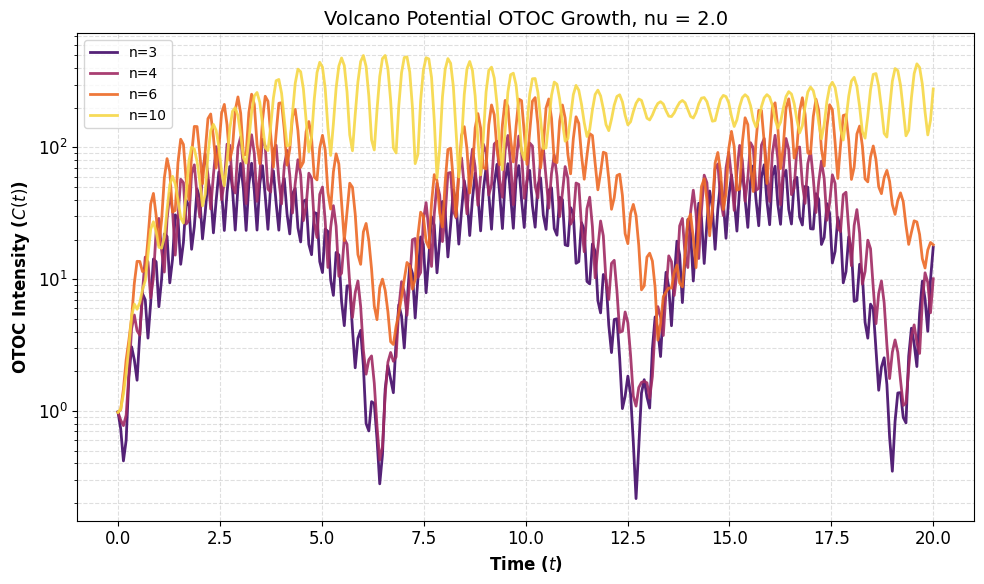

In [41]:
# Plot raw OTOC growth for selected states
plt.figure(figsize=(10, 6), dpi=100)
select_n = [3,4,6,10] # Select a few states to visualize
colors = cm.inferno(np.linspace(0.2, 0.9, len(select_n)))

for i, n in enumerate(select_n):
    if n < len(OTOC_list):
        plt.plot(t_range, OTOC_list[n], label=f'n={n}', color=colors[i], linewidth=2, alpha=0.9)

plt.grid(True, which="both", ls="--", alpha=0.4)  
plt.yscale('log')
plt.xlabel('Time ($t$)', fontsize=12, fontweight='bold')
plt.ylabel('OTOC Intensity ($C(t)$)', fontsize=12, fontweight='bold')
plt.title(f'Volcano Potential OTOC Growth, nu = {nu}', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout() 
plt.show()

Calculating Theoretical Sensitivities...
Computing for states n = 0 to 29
  ✓ Calculated states 0-4 (5 valid)
  ✓ Calculated states 0-9 (10 valid)
  ✓ Calculated states 0-14 (15 valid)
  ✓ Calculated states 0-19 (20 valid)
  ✓ Calculated states 0-24 (25 valid)
  ✓ Calculated states 0-29 (30 valid)

✓ Successfully calculated 30 out of 30 states


<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\risha\AppData\Local\Temp\ipykernel_16556\2761064375.py:62: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Growth Rate ($2\lambda$)', fontsize=13)


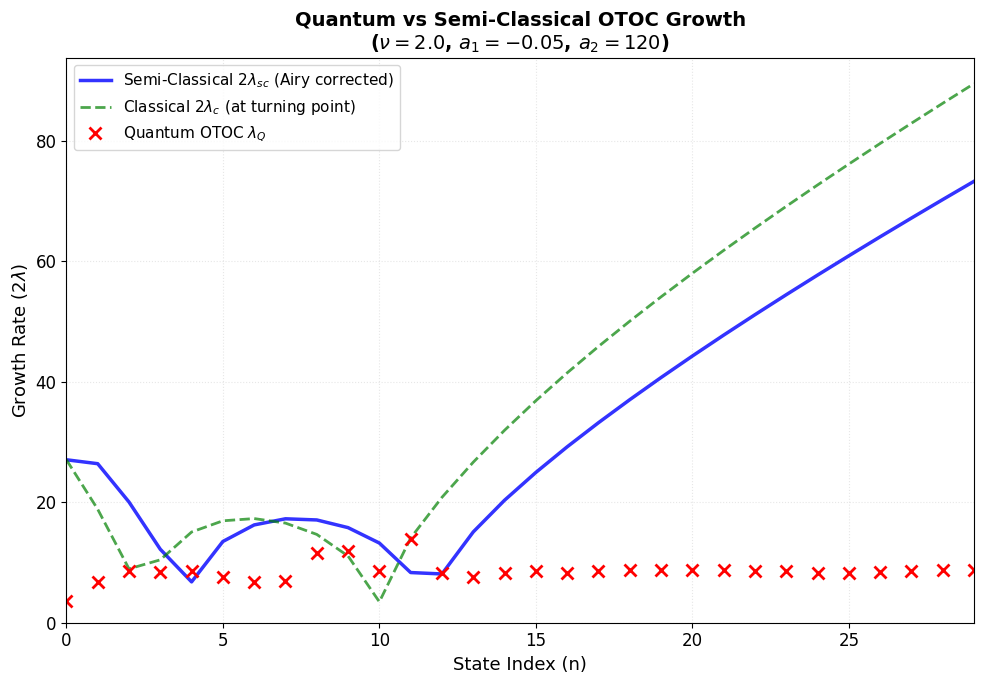


✓ Plot created with 30 semi-classical points


In [42]:
print("Calculating Theoretical Sensitivities...")

n_range = range(min(limit_n_plot, n_states_sim))
lambda_sc_list = []
lambda_c_list = []
valid_n_indices = []

print(f"Computing for states n = 0 to {len(n_range)-1}")

# Calculate sensitivities for each state
for n in n_range:
    E_n = energies[n]
    
    # Semi-classical
    try:
        l_sc = calculate_lambda_semiclassical(E_n, a1, a2, nu)
        if np.isnan(l_sc) or np.isinf(l_sc):
            print(f"  State {n}: E={E_n:.6f} → λ_sc is NaN/Inf (skipping)")
            continue
    except Exception as e:
        print(f"  State {n}: Error in calculation: {e}")
        continue
    
 
    try:
        l_c = calculate_lambda_classical(E_n, a1, a2, nu)
    except:
        l_c = l_sc  # Fallback
    
    lambda_sc_list.append(l_sc)
    lambda_c_list.append(l_c)
    valid_n_indices.append(n)
    
    # Progress indicator every 5 states
    if (n + 1) % 5 == 0:
        print(f"  ✓ Calculated states 0-{n} ({len(valid_n_indices)} valid)")

print(f"\n✓ Successfully calculated {len(valid_n_indices)} out of {len(n_range)} states")

# Convert to arrays
lambda_sc_array = np.array(lambda_sc_list)
lambda_c_array = np.array(lambda_c_list)

# Create the plot
plt.figure(figsize=(10, 7))

# Plot Semi-Classical (blue line)
plt.plot(valid_n_indices, 2 * lambda_sc_array, 'b-', linewidth=2.5, 
         label=r'Semi-Classical $2\lambda_{sc}$ (Airy corrected)', alpha=0.8)

# Plot Classical (green dashed line) 
plt.plot(valid_n_indices, 2 * lambda_c_array, 'g--', linewidth=2, 
         label=r'Classical $2\lambda_{c}$ (at turning point)', alpha=0.7)

# Plot Quantum OTOC results (red crosses)

n_quantum = min(len(valid_n_indices), len(otoc_slopes))
plt.plot(valid_n_indices[:n_quantum],  otoc_slopes[:n_quantum], 'rx', 
         markersize=8, markeredgewidth=2, label=r'Quantum OTOC $\lambda_{Q}$')

plt.xlabel('State Index (n)', fontsize=13)
plt.ylabel('Growth Rate ($2\lambda$)', fontsize=13)
plt.title(f'Quantum vs Semi-Classical OTOC Growth\n($\\nu={nu}$, $a_1={a1}$, $a_2={a2}$)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, linestyle=':')
#plt.xlim(0,14)
plt.xlim(0, max(valid_n_indices) if valid_n_indices else 10)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()



print(f"\n✓ Plot created with {len(valid_n_indices)} semi-classical points")

In [43]:
"""for i in range(10, 20):
    print(i, lambda_sc_array[i])"""

'for i in range(10, 20):\n    print(i, lambda_sc_array[i])'

Calculating Theoretical Sensitivities...


<>:26: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:26: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\risha\AppData\Local\Temp\ipykernel_16556\3200961512.py:26: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.ylabel('Sensitivity Parameter $\lambda$')


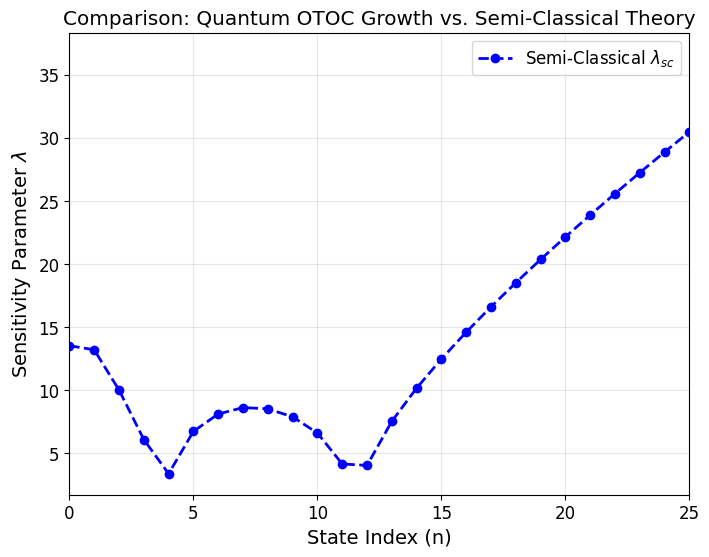

In [44]:
print("Calculating Theoretical Sensitivities...")
lambda_sc_list = []
valid_n_indices = []


for n in n_range:
    E_n = energies[n] # Get the energy eigenvalue for state n
    
    
    l_sc = get_lambda_sc_for_state(E_n, a1, a2, nu)
    
    lambda_sc_list.append(l_sc)
    valid_n_indices.append(n)


plt.figure(figsize=(8, 6))


plt.plot(valid_n_indices, lambda_sc_list, 'o--', color='blue', label=r'Semi-Classical $\lambda_{sc}$')


if 'otoc_slopes' in locals() and len(otoc_slopes) == len(valid_n_indices):
    plt.plot(valid_n_indices, otoc_slopes, 'rx', label=r'Quantum OTOC $\lambda_{Q}$')

plt.xlabel('State Index (n)')
plt.ylabel('Sensitivity Parameter $\lambda$')
plt.title(r'Comparison: Quantum OTOC Growth vs. Semi-Classical Theory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 25)
plt.show()

Plot 2: Quantum-Classical Correspondence

In [45]:
"""# --- PLOTTING ROUTINE ---

# 1. Theoretical Curves (Scan entire energy range)
# We assume the energy range is bounded roughly by the potential at the wall
E_theory = np.linspace(np.min(energies), np.max(energies), 200)
idx_th, lam_c_th, lam_sc_th = calculate_sensitivities(E_theory, a1, a2, nu, mass, x_max=10.0)
E_theory_plot = E_theory[idx_th]

# 2. Simulation Points (Calculate for specific eigenstates)
idx_sim, lam_c_sim, lam_sc_sim = calculate_sensitivities(energies, a1, a2, nu, mass, x_max=10.0)
sim_energies = energies[idx_sim]

# Filter OTOC rates to match valid indices
sim_rates_filtered = []
for k in idx_sim:
    if k < len(otoc_slopes):
        sim_rates_filtered.append(otoc_slopes[k])
    else:
        sim_rates_filtered.append(np.nan)

# 3. Generate Figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# Plot Theory
if len(E_theory_plot) > 0:
    ax.plot(E_theory_plot, 2 * lam_c_th, 'b--', alpha=0.6, label=r'Classical Theory ($2\lambda_{cl}$)')
    ax.plot(E_theory_plot, 2 * lam_sc_th, 'g-', linewidth=2, label=r'Semiclassical Theory ($2\lambda_{sc}$)')

# Plot Simulation
if len(sim_energies) > 0:
    ax.scatter(sim_energies, sim_rates_filtered, color='#d62728', s=30, 
               edgecolor='white', linewidth=0.5, label='Simulated OTOC Growth')

ax.set_xlabel(r'Energy ($E$)', fontsize=12)
ax.set_ylabel(r'Lyapunov / Growth Rate', fontsize=12)
ax.set_title(r'Quantum-Classical Correspondence (Hard Wall Enforced)', fontsize=14)
ax.legend(loc='best', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

# Set limits to focus on the data
if len(energies) > 0:
    ax.set_xlim(np.min(energies), np.max(energies))
ax.set_ylim(bottom=-0.01)
ax.set_xlim(0, 350)
plt.tight_layout()
plt.show()
"""

<>:26: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:26: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\risha\AppData\Local\Temp\ipykernel_16556\854655061.py:26: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax.plot(E_theory_plot, 2 * lam_c_th, 'b--', alpha=0.6, label=r'Classical Theory ($2\lambda_{cl}$)')


"# --- PLOTTING ROUTINE ---\n\n# 1. Theoretical Curves (Scan entire energy range)\n# We assume the energy range is bounded roughly by the potential at the wall\nE_theory = np.linspace(np.min(energies), np.max(energies), 200)\nidx_th, lam_c_th, lam_sc_th = calculate_sensitivities(E_theory, a1, a2, nu, mass, x_max=10.0)\nE_theory_plot = E_theory[idx_th]\n\n# 2. Simulation Points (Calculate for specific eigenstates)\nidx_sim, lam_c_sim, lam_sc_sim = calculate_sensitivities(energies, a1, a2, nu, mass, x_max=10.0)\nsim_energies = energies[idx_sim]\n\n# Filter OTOC rates to match valid indices\nsim_rates_filtered = []\nfor k in idx_sim:\n    if k < len(otoc_slopes):\n        sim_rates_filtered.append(otoc_slopes[k])\n    else:\n        sim_rates_filtered.append(np.nan)\n\n# 3. Generate Figure\nfig, ax = plt.subplots(figsize=(8, 6), dpi=120)\n\n# Plot Theory\nif len(E_theory_plot) > 0:\n    ax.plot(E_theory_plot, 2 * lam_c_th, 'b--', alpha=0.6, label=r'Classical Theory ($2\\lambda_{cl}$)')\n 

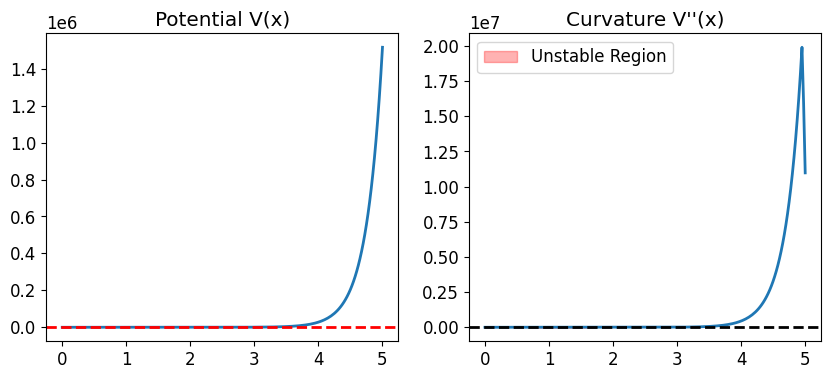

In [46]:
# Quick Diagnostic Plot
import matplotlib.pyplot as plt
x_test = np.linspace(0, 5, 200)
V_test = -(a1 * np.cosh(x_test)**(2*nu) + a2 * (1/np.cosh(x_test))**2)
Curvature_test = np.gradient(np.gradient(V_test, x_test), x_test)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(x_test, V_test)
plt.title("Potential V(x)")
plt.axhline(y=energies[10], color='r', linestyle='--', label=f'E={energies[10]:.1f}') # Check low energy intersection

plt.subplot(1,2,2)
plt.plot(x_test, Curvature_test)
plt.title("Curvature V''(x)")
plt.axhline(0, color='k', linestyle='--')
plt.fill_between(x_test, Curvature_test, 0, where=(Curvature_test < 0), color='red', alpha=0.3, label='Unstable Region')
plt.legend()
plt.show()

In [47]:
"""import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. GLOBAL PAPER CONFIGURATION
# ==========================================
# Use standard publication style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})

CONFIG = {
    'a1': -0.5,
    'a2': 20.0,
    'nus': [-2, -1, 0, 1, 2],
    # Consistent color palette for the 5 nu values
    'colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] 
}

def V(x, nu):
    return -(CONFIG['a1'] * np.cosh(x)**(2*nu) + CONFIG['a2'] * (1/np.cosh(x))**2)

def double_derivative(x, y):

    return np.gradient(np.gradient(y, x), x)

# ==========================================
# CURVE 1: Potential Plots
# ==========================================
def plot_curve1_potential_panels():
  
    x = np.linspace(-4, 4, 400)
    
    # Create a 1x5 grid of subplots
    fig, axs = plt.subplots(1, len(CONFIG['nus']), figsize=(18, 4))
    
    for i, (nu, color) in enumerate(zip(CONFIG['nus'], CONFIG['colors'])):
        y = V(x, nu)
        
        # Plot the potential in its respective panel
        axs[i].plot(x, y, color=color, linewidth=2)
        
        # Formatting each panel
        axs[i].set_title(rf'$\nu = {nu}$')
        axs[i].set_xlabel("Position ($x$)")
        axs[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axs[i].grid(alpha=0.3)
        
        # Set a dynamic y-limit to focus on the well and the turning points
        # We cap the top at 50 so the nu=2 walls don't ruin the scale
        axs[i].set_ylim(-110, 50) 
        
        # Only add the y-axis label to the leftmost plot to keep it clean
        if i == 0:
            axs[i].set_ylabel("Potential $V(x)$")

    # Add a main title above all panels
    plt.suptitle("Potential Well Profiles for Varying $\\nu$", y=1.05, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# CURVE 2: OTOC Growth (Short & Long Time)
# ==========================================
def plot_curve2_otoc_growth(t_short, otoc_short_data, t_long, otoc_long_data):
   
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    for nu, color in zip(CONFIG['nus'], CONFIG['colors']):
        # Panel 1: Short Time (usually log scale to show exponential growth e^{2\lambda t})
        ax1.plot(t_short, otoc_short_data[nu], label=rf'$\nu = {nu}$', color=color)
        
        # Panel 2: Long Time (shows saturation/scrambling time)
        ax2.plot(t_long, otoc_long_data[nu], label=rf'$\nu = {nu}$', color=color)

    # Formatting Short Time
    ax1.set_title("OTOC Growth (Short Time Scale)")
    ax1.set_xlabel("Time ($t$)")
    ax1.set_ylabel("$C(t)$ (Log Scale)")
    ax1.set_yscale('log')
    ax1.grid(alpha=0.3)
    ax1.legend()
    
    # Formatting Long Time
    ax2.set_title("OTOC Saturation (Long Time Scale)")
    ax2.set_xlabel("Time ($t$)")
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# CURVE 3: Turning Point / Stability Curves
# ==========================================
def plot_curve3_stability():
    x = np.linspace(-4, 4, 400)
    
    # Create a panel for each nu to avoid a messy plot
    fig, axs = plt.subplots(1, len(CONFIG['nus']), figsize=(18, 4), sharey=True)
    
    for i, (nu, color) in enumerate(zip(CONFIG['nus'], CONFIG['colors'])):
        potential = V(x, nu)
        curvature = double_derivative(x, potential)
        
        axs[i].plot(x, curvature, color=color, label=f"$V''(x)$")
        axs[i].axhline(0, color='black', linestyle='--', linewidth=0.8)
        
        # Highlight unstable regions (where curvature is negative)
        axs[i].fill_between(x, curvature, 0, where=(curvature < 0), 
                            color='red', alpha=0.2, label='Unstable ($V\'\'<0$)')
        
        axs[i].set_title(rf"$\nu = {nu}$")
        axs[i].set_xlabel("$x$")
        if i == 0:
            axs[i].set_ylabel("Curvature $V''(x)$")
            axs[i].legend(loc='upper right', fontsize=9)
            
    # Limit y-axis to see the bottom of the curvature well
    plt.ylim(-300, 300)
    plt.tight_layout()
    plt.show()

# ==========================================
# CURVE 4: Lambda Comparison
# ==========================================
def plot_curve4_lambda_comparison(lambda_classical, lambda_semiclassical):
   
    fig, axs = plt.subplots(1, len(CONFIG['nus']), figsize=(15, 4), sharey=True)
    
    # X-axis labels for the bars
    labels = ['Classical', 'Semi-Classical']
    x_pos = np.arange(len(labels))
    
    for i, (nu, color) in enumerate(zip(CONFIG['nus'], CONFIG['colors'])):
        l_c = lambda_classical[nu]
        l_sc = lambda_semiclassical[nu]
        
        # Plot bars
        axs[i].bar(x_pos, [l_c, l_sc], color=[color, 'gray'], alpha=0.8, edgecolor='black')
        
        axs[i].set_title(rf"$\nu = {nu}$")
        axs[i].set_xticks(x_pos)
        axs[i].set_xticklabels(labels)
        
        if i == 0:
            axs[i].set_ylabel("Lyapunov Exponent ($\lambda$)")

    plt.suptitle("Comparison of Classical vs Semi-Classical Lyapunov Exponents", y=1.05)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 1. Plot Potential
    plot_curve1_potential()
    
    # 2. Plot OTOC (Using dummy data - replace with your arrays)
    t_s = np.linspace(0, 2, 100)
    t_l = np.linspace(0, 10, 500)
    # mock_short = {nu: np.exp(0.5 * t_s * (nu+3)) for nu in CONFIG['nus']}
    # mock_long = {nu: 1 - np.exp(-0.2 * t_l * (nu+3)) for nu in CONFIG['nus']}
    # plot_curve2_otoc_growth(t_s, mock_short, t_l, mock_long)
    
    # 3. Plot Stability
    plot_curve3_stability()
    
    # 4. Plot Lambdas (Using dummy data - replace with your floats)
    # mock_lc = {nu: 0.5 + 0.1*nu for nu in CONFIG['nus']}
    # mock_lsc = {nu: 0.45 + 0.08*nu for nu in CONFIG['nus']}
    # plot_curve4_lambda_comparison(mock_lc, mock_lsc)
    """

<>:75: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:75: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\risha\AppData\Local\Temp\ipykernel_16556\1090337459.py:75: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  # Panel 1: Short Time (usually log scale to show exponential growth e^{2\lambda t})


'import numpy as np\nimport matplotlib.pyplot as plt\n\n# ==========================================\n# 0. GLOBAL PAPER CONFIGURATION\n# ==========================================\n# Use standard publication style\nplt.style.use(\'default\')\nplt.rcParams.update({\n    \'font.size\': 12,\n    \'axes.labelsize\': 14,\n    \'legend.fontsize\': 11,\n    \'lines.linewidth\': 2\n})\n\nCONFIG = {\n    \'a1\': -0.5,\n    \'a2\': 20.0,\n    \'nus\': [-2, -1, 0, 1, 2],\n    # Consistent color palette for the 5 nu values\n    \'colors\': [\'#1f77b4\', \'#ff7f0e\', \'#2ca02c\', \'#d62728\', \'#9467bd\'] \n}\n\ndef V(x, nu):\n    return -(CONFIG[\'a1\'] * np.cosh(x)**(2*nu) + CONFIG[\'a2\'] * (1/np.cosh(x))**2)\n\ndef double_derivative(x, y):\n\n    return np.gradient(np.gradient(y, x), x)\n\n# ==========================================\n# CURVE 1: Potential Plots\n# ==========================================\ndef plot_curve1_potential_panels():\n\n    x = np.linspace(-4, 4, 400)\n\n    # Create a

Plotting Function used for Potential vs x and Turning point 

Generating Plot 1...


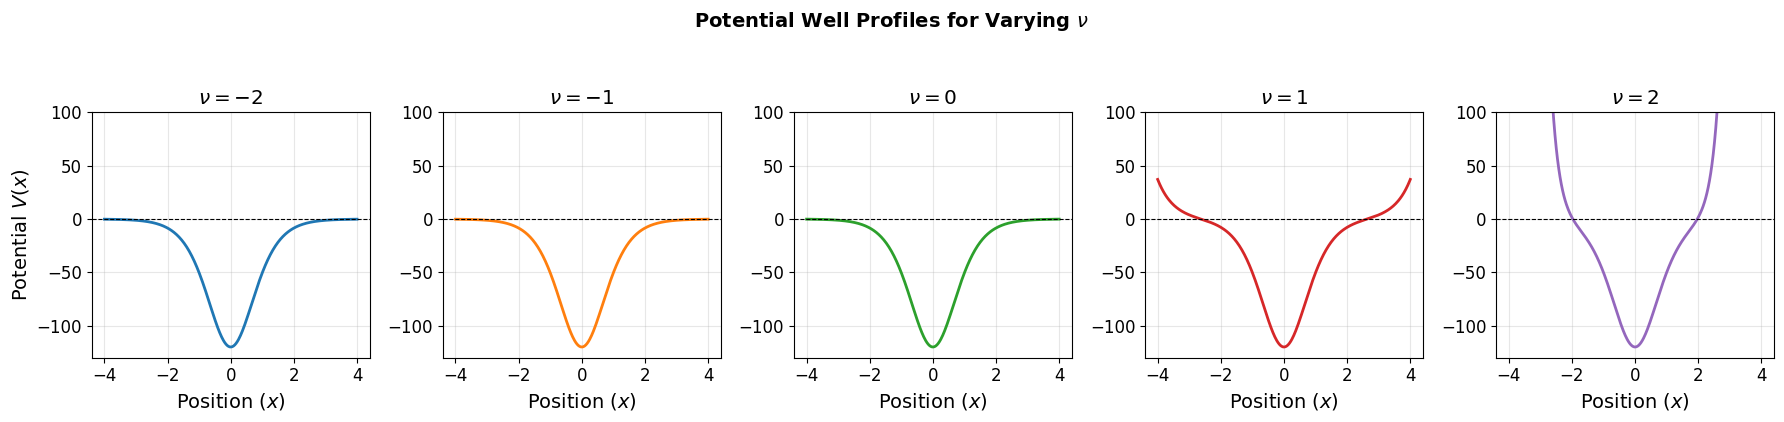

Generating Plot 3...


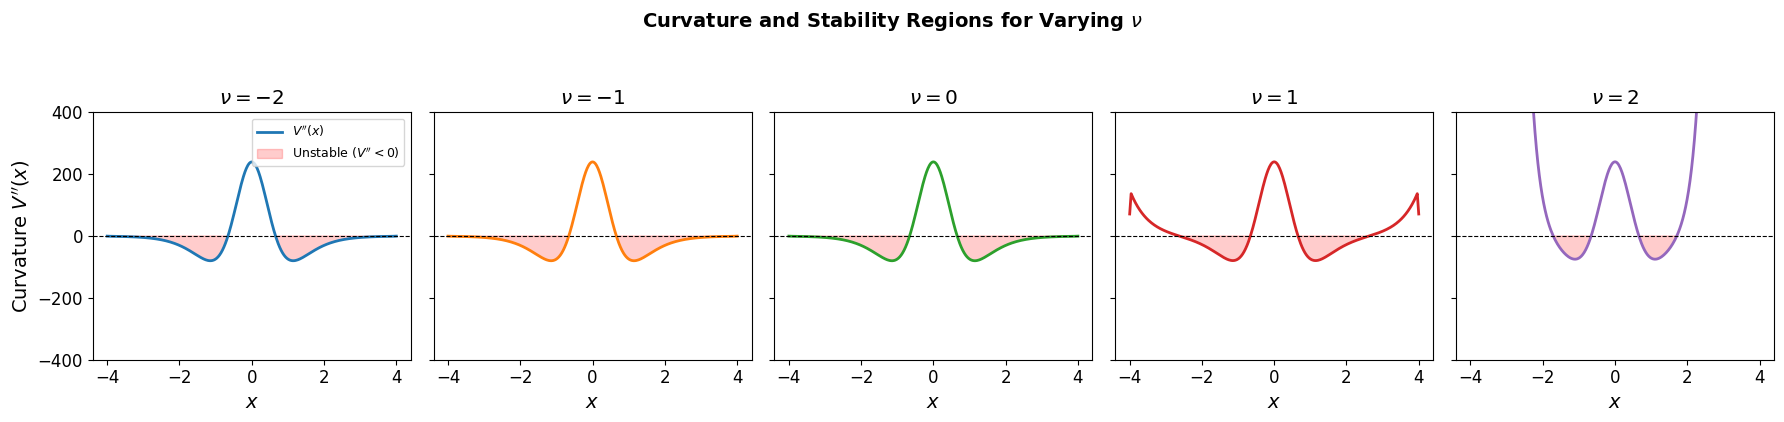

In [48]:

plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})

CONFIG = {
    'a1': -0.05,
    'a2': 120.0,
    'nus': [-2, -1, 0, 1, 2],
    'colors': ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] 
}

def V(x, nu):
    """The central potential function."""
    return -(CONFIG['a1'] * np.cosh(x)**(2*nu) + CONFIG['a2'] * (1/np.cosh(x))**2)

def double_derivative(x, y):
    """Numerical second derivative."""
    return np.gradient(np.gradient(y, x), x)


def plot_curve1_potential_panels():
    x = np.linspace(-4, 4, 400)
    
    fig, axs = plt.subplots(1, len(CONFIG['nus']), figsize=(18, 4))
    
    for i, (nu, color) in enumerate(zip(CONFIG['nus'], CONFIG['colors'])):
        y = V(x, nu)
        
        axs[i].plot(x, y, color=color, linewidth=2)
        axs[i].set_title(rf'$\nu = {nu}$')
        axs[i].set_xlabel("Position ($x$)")
        axs[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axs[i].grid(alpha=0.3)
        
    
        axs[i].set_ylim(-130, 100) 
        
        if i == 0:
            axs[i].set_ylabel("Potential $V(x)$")

    plt.suptitle("Potential Well Profiles for Varying $\\nu$", y=1.05, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_curve3_stability():
    x = np.linspace(-4, 4, 400)
    
    fig, axs = plt.subplots(1, len(CONFIG['nus']), figsize=(18, 4), sharey=True)
    
    for i, (nu, color) in enumerate(zip(CONFIG['nus'], CONFIG['colors'])):
        potential = V(x, nu)
        curvature = double_derivative(x, potential)
        
        axs[i].plot(x, curvature, color=color, label=f"$V''(x)$")
        axs[i].axhline(0, color='black', linestyle='--', linewidth=0.8)
        

        axs[i].fill_between(x, curvature, 0, where=(curvature < 0), 
                            color='red', alpha=0.2, label='Unstable ($V\'\'<0$)')
        
        axs[i].set_title(rf"$\nu = {nu}$")
        axs[i].set_xlabel("$x$")
        
      
        axs[i].set_ylim(-400, 400)
        
        if i == 0:
            axs[i].set_ylabel("Curvature $V''(x)$")
            axs[i].legend(loc='upper right', fontsize=9)
            
    plt.suptitle("Curvature and Stability Regions for Varying $\\nu$", y=1.05, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    print("Generating Plot 1...")
    plot_curve1_potential_panels()
    
    print("Generating Plot 3...")
    plot_curve3_stability()

Generating Potential Profile Plots...


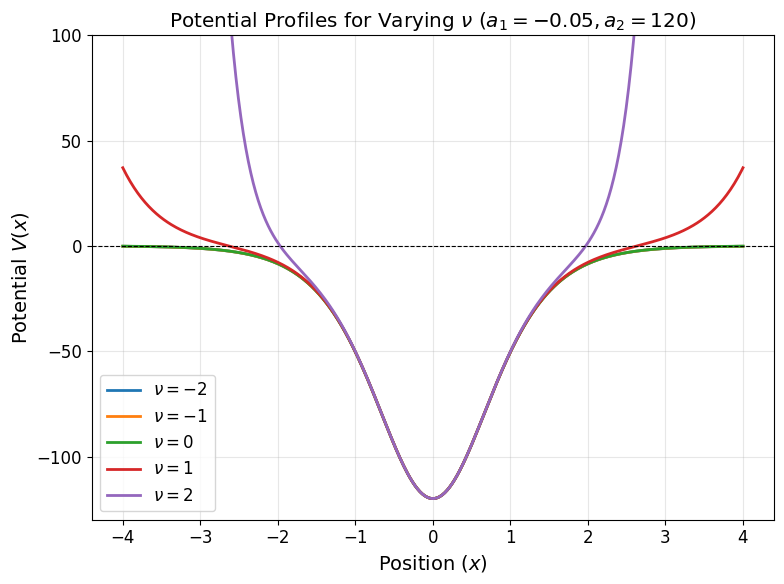

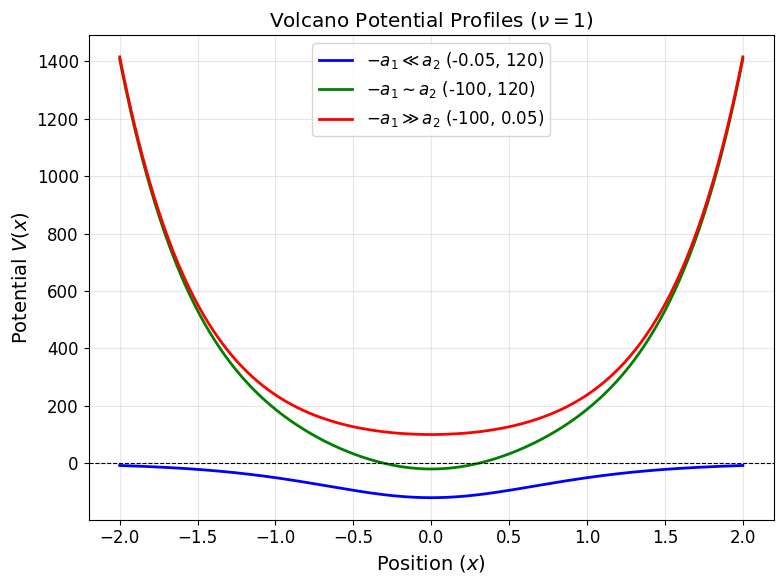


Beginning OTOC Simulations for ν=0 configurations...
  -> Simulating config: a1= -0.05, a2= 120.0 (State n=5)
  -> Simulating config: a1=-100.0, a2= 120.0 (State n=5)
  -> Simulating config: a1=-100.0, a2=  0.05 (State n=5)

Simulations complete. Generating OTOC Growth Comparison Plots...


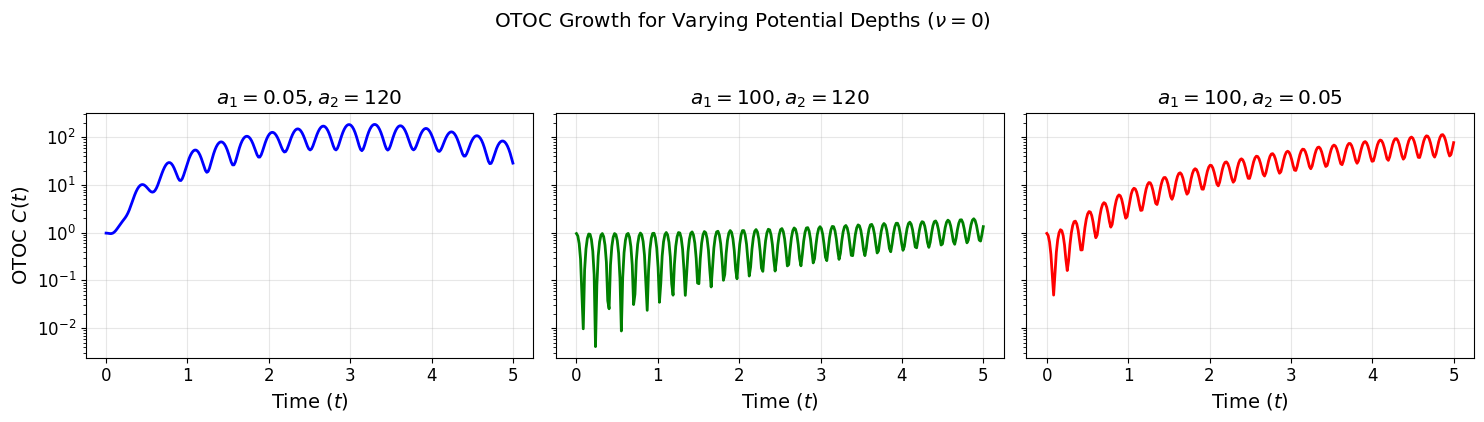

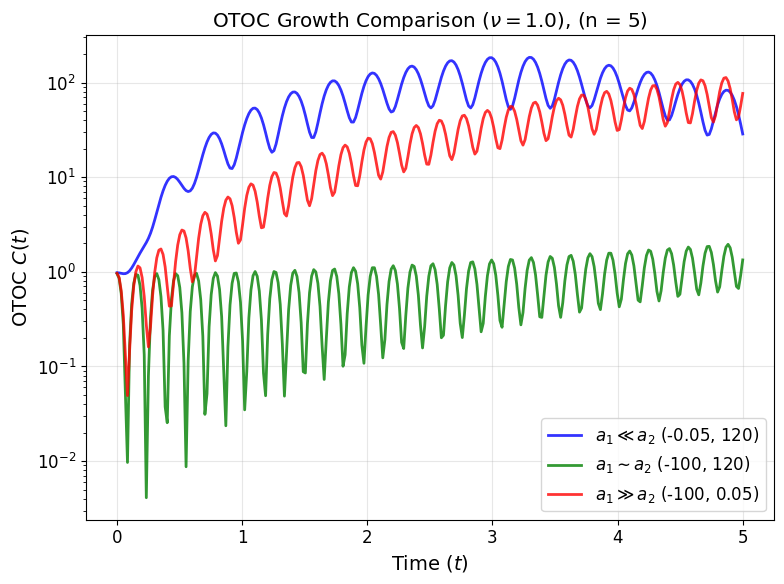

Pipeline Finished.


In [49]:
# Global formatting for publication
plt.style.use('default')
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'lines.linewidth': 2})

def V(x, a1, a2, nu):
    """General Volcano Potential"""
    return -(a1 * np.cosh(x)**(2*nu) + a2 * (1/np.cosh(x))**2)

# ==========================================
# PLOT 1: Single Panel, Varying Nu (Fixed a1, a2)
# ==========================================
def plot1_single_panel_varying_nu():
    x = np.linspace(-4, 4, 500)
    nus = [-2, -1, 0, 1, 2]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    plt.figure(figsize=(8, 6))
    for nu, color in zip(nus, colors):
        plt.plot(x, V(x, a1=-0.05, a2=120.0, nu=nu), label=rf'$\nu = {nu}$', color=color)
        
    plt.title(r"Potential Profiles for Varying $\nu$ ($a_1=-0.05, a_2=120$)")
    plt.xlabel("Position ($x$)")
    plt.ylabel("Potential $V(x)$")
    plt.ylim(-130, 100) # Restrict Y so nu=2 doesn't compress everything
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# PLOT 2: Single Panel, Fixed Nu=0, Varying a1, a2
# ==========================================
def plot2_single_panel_varying_a():
    x = np.linspace(-2, 2, 500)
    configs = [
        {'a1': -0.05, 'a2': 120, 'label': r'$-a_1 \ll a_2$ (-0.05, 120)', 'color': 'blue'},
        {'a1': -100,  'a2': 120, 'label': r'$-a_1 \sim a_2$ (-100, 120)', 'color': 'green'},
        {'a1': -100,  'a2': 0.05, 'label': r'$-a_1 \gg a_2$ (-100, 0.05)', 'color': 'red'}
    ]
    
    plt.figure(figsize=(8, 6))
    for config in configs:
        y = V(x, a1=config['a1'], a2=config['a2'], nu=1)
        plt.plot(x, y, label=config['label'], color=config['color'])
        
    plt.title(r"Volcano Potential Profiles ($\nu=1$)")
    plt.xlabel("Position ($x$)")
    plt.ylabel("Potential $V(x)$")
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# PLOT 3: OTOC Growth 3 Panels (Varying a1, a2)
# ==========================================
def plot3_otoc_three_panels(time_array, otoc_data):
    """
    otoc_data should be a list of 3 arrays corresponding to the 3 configs.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    labels = [r'$a_1=0.05, a_2=120$', r'$a_1=100, a_2=120$', r'$a_1=100, a_2=0.05$']
    colors = ['blue', 'green', 'red']
    
    for i in range(3):
        axs[i].plot(time_array, otoc_data[i], color=colors[i])
        axs[i].set_title(labels[i])
        axs[i].set_xlabel("Time ($t$)")
        axs[i].set_yscale('log')
        axs[i].grid(alpha=0.3)
        if i == 0:
            axs[i].set_ylabel("OTOC $C(t)$")
            
    plt.suptitle(r"OTOC Growth for Varying Potential Depths ($\nu=0$)", y=1.05)
    plt.tight_layout()
    plt.show()

# ==========================================
# PLOT 4: OTOC Growth 1 Panel Comparison
# ==========================================
def plot4_otoc_comparison_single_panel(time_array, otoc_data):
    plt.figure(figsize=(8, 6))
    labels = [r'$a_1 \ll a_2$ (-0.05, 120)', r'$a_1 \sim a_2$ (-100, 120)', r'$a_1 \gg a_2$ (-100, 0.05)']
    colors = ['blue', 'green', 'red']
    
    for i in range(3):
        # Using dashed line for the second one because it will perfectly overlap the first!
        linestyle = '-' if i == 1 else '-'
        #linesyle = '-' 
        plt.plot(time_array, otoc_data[i], label=labels[i], color=colors[i], linestyle=linestyle, alpha=0.8)
        
    plt.title(r"OTOC Growth Comparison ($\nu=1.0$), (n = 5)")
    plt.xlabel("Time ($t$)")
    plt.ylabel("OTOC $C(t)$")
    plt.yscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION PIPELINE (Integrated with run_simulation_fast)
# ==========================================

if __name__ == "__main__":
    print("Generating Potential Profile Plots...")
    # NOTE: Ensure these functions from the previous step are defined above
    plot1_single_panel_varying_nu()
    plot2_single_panel_varying_a()
    
    print("\nBeginning OTOC Simulations for \u03bd=0 configurations...")
    
    # Define the configurations
    configurations = [
        {'a1': -0.05, 'a2': 120.0, 'label': '|a1| << a2'},
        {'a1': -100.0, 'a2': 120.0, 'label': '|a1| ~ a2'},
        {'a1': -100.0, 'a2': 0.05,  'label': '|a1| >> a2'}
    ]
    
    # Store results for Plot 3 and Plot 4
    otoc_data_list = []

    t_max = 5.0
    
    # Match the time array generated inside your run_simulation_fast
    # Make sure t_max is defined in your notebook (e.g., t_max = 50.0)
    time_array = np.linspace(0, t_max, 300) 
    
    # Select a highly-excited bound state to clearly see the scrambling/curvature effects
    n_target = 5 
    # Make sure N is defined in your notebook (e.g., N = 512 or 1024)
    
    for config in configurations:
        print(f"  -> Simulating config: a1={config['a1']:>6}, a2={config['a2']:>6} (State n={n_target})")
        
        # 1. Update Global Variables
        # This is CRITICAL because energy_matrices() relies on global a1 and a2
        global a1, a2
        a1 = config['a1']
        a2 = config['a2']
        
        # 2. Run your fast vectorized simulation
        otoc_values = run_simulation_fast(N, t_max, n_target, nu=1.0)
        
        # 3. Store the real part of the array for plotting
        otoc_data_list.append(np.real(otoc_values))
    
    print("\nSimulations complete. Generating OTOC Growth Comparison Plots...")
    
    # Pass the simulated data to the plotting functions
    plot3_otoc_three_panels(time_array, otoc_data_list)
    plot4_otoc_comparison_single_panel(time_array, otoc_data_list)
    
    print("Pipeline Finished.")

In [61]:
def calculate_ehrenfest_time(lambda_val, L_box, N_points):
    """
    Calculates the Ehrenfest time for a specific state based on its 
    semi-classical Lyapunov exponent.
    """
    # If there is no instability (stable state), there is no Ehrenfest scrambling time
    if lambda_val is None or np.isnan(lambda_val) or lambda_val <= 1e-10:
        return np.nan
        
    hbar_eff = 1.0 / N_points
    # Standard Ehrenfest definition using the base Lyapunov exponent
    t_E = (1.0 / lambda_val) * np.log(L_box / np.sqrt(hbar_eff))
    return t_E

def get_otoc_growth_rates(time_array, otoc_data_list, t_max_fit_list):
    """
    Extracts the max instantaneous growth rate, dynamically restricting 
    the search window to the Ehrenfest time for each specific state.
    """
    rates = []
    dt = time_array[1] - time_array[0]
    window_size = 3 
    
    for i, otoc_series in enumerate(otoc_data_list):
        t_max_fit = t_max_fit_list[i]
        
        # 1. Check if the state is physically stable (No Ehrenfest time)
        #if np.isnan(t_max_fit):
            #rates.append(0.0)
            #continue
            
        # Clean Data
        y_clean = np.maximum(np.array(otoc_series), 1e-15)
        log_y = np.log(y_clean)
        
        # Derivative d(ln C)/dt
        d_log_dt = np.gradient(log_y, dt)
        smoothed_rate = np.convolve(d_log_dt, np.ones(window_size)/window_size, mode='valid')
        
        # 2. Dynamic Search Limit (The Ehrenfest Window)
        search_limit_idx = np.searchsorted(time_array, t_max_fit)
        
        # Ensure the index doesn't exceed the array length if t_E > total simulation time
        valid_limit = min(search_limit_idx, len(smoothed_rate))
        
        if valid_limit > 0:
             max_rate = np.max(smoothed_rate[:valid_limit])
        else:
             max_rate = 0.0 # Fallback if window is impossibly small
        
        # 3. Filter stable harmonic states (must grow 5x to be considered scrambling)
        initial_val = np.mean(y_clean[:5])
        max_val = np.max(y_clean)
        rates.append(max(0, max_rate))
            
    return np.array(rates)

Generating Potential Profile Plots...

Starting Unified Lambda Comparison Simulation...

Processing Config 1: nu=0.0 (a1=-0.05, a2=120.0)
  -> Running theoretical and quantum calculations for 20 states...

Processing Config 2: nu=1.0 (a1=-0.05, a2=120.0)
  -> Running theoretical and quantum calculations for 20 states...

Processing Config 3: nu=2.0 (a1=-0.05, a2=120.0)
  -> Running theoretical and quantum calculations for 20 states...


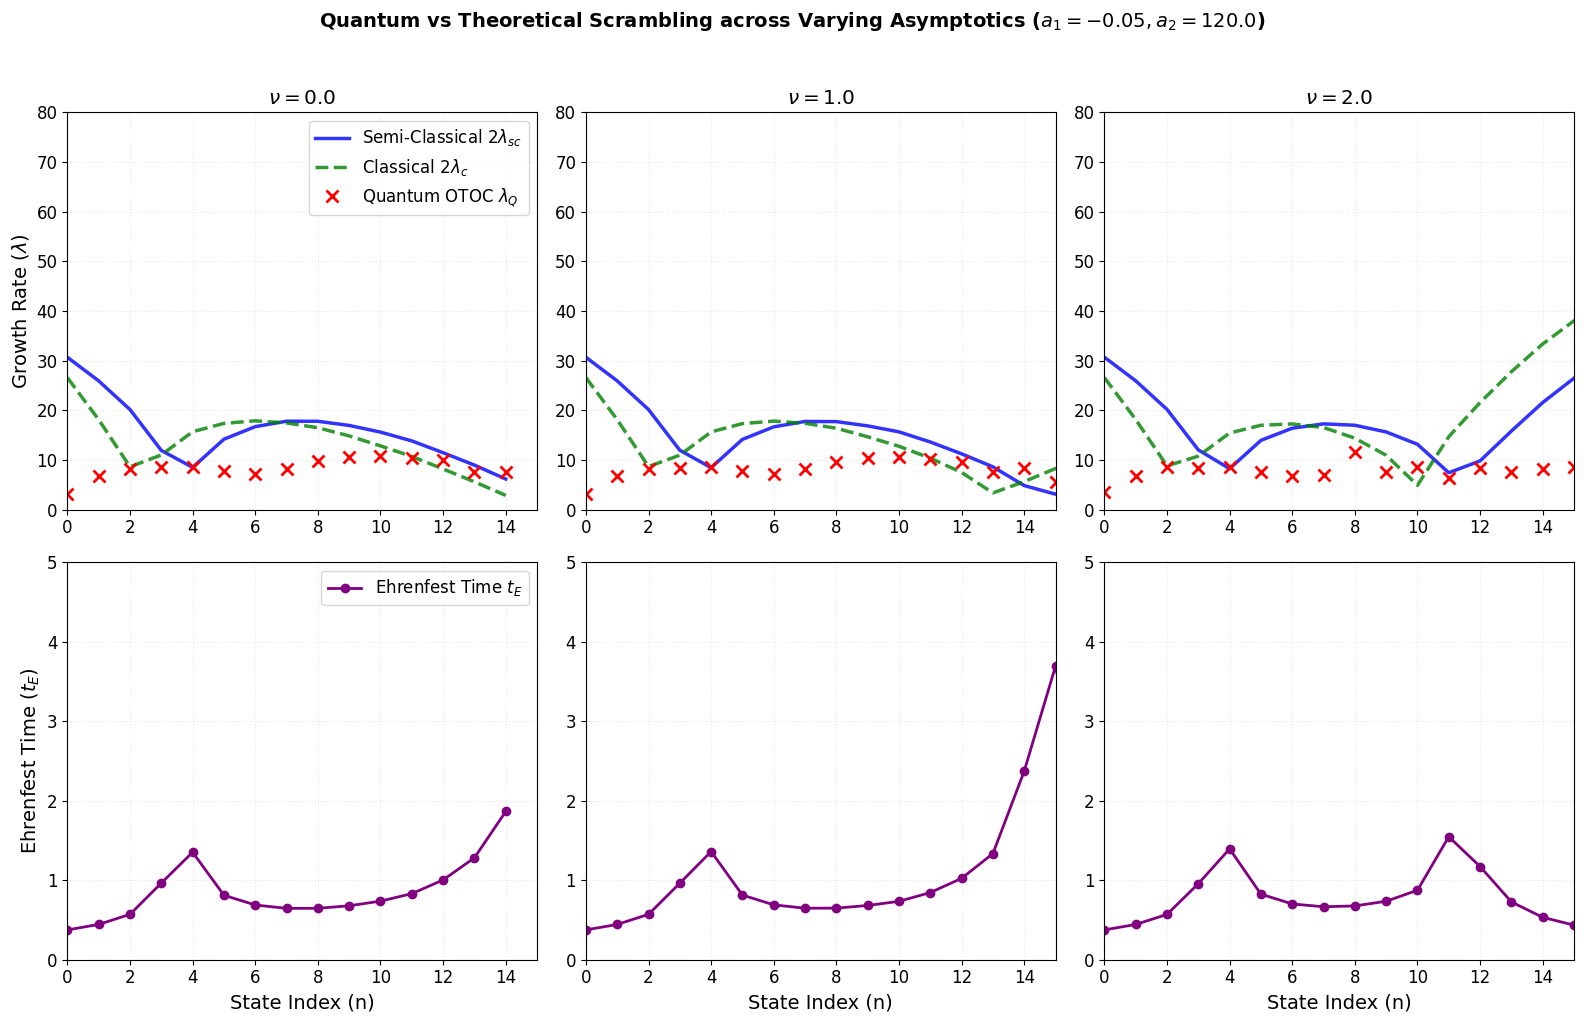

In [ ]:
HBAR = 1.0
MU = 1.0

def plot_lambda_comparisons(N_points, L_box, t_max):

    a1 = -0.05
    a2  = 120.0
    nu_list = [0.0, 1.0, 2.0]
    
    # UPGRADED to 2 rows, 3 columns
    fig, axs = plt.subplots(2, 3, figsize=(16, 10))
    
    # Time array required for the growth rate extraction
    time_array = np.linspace(0, t_max, 300)
    
    for i, nu_value in enumerate(nu_list):
        print(f"\nProcessing Config {i+1}: nu={nu_value} (a1={a1}, a2={a2})")
        
        # 2. Call established notebook functions
        x_grid, dx = build_Grid(L_box, N_points)
        V_grid, V_prime, V_double_prime = volcano_derivatives(x_grid, a1, a2, nu_value)
        _, _, energies = energy_matrices(x_grid, dx, nu_value)
        
        # 3. Setup lists to store data for this specific configuration
        n_vals, l_c, l_sc = [], [], []
        otoc_series_list = [] # Will hold the raw time-series for the quantum extraction
        t_max_fit_list = [] # To store the Ehrenfest time for each state    
        t_E_raw_list = [] 
        
        x_right_idx = np.where(x_grid >= 0)[0]
        max_states_to_plot = min(20, len(energies))
        
        print(f"  -> Running theoretical and quantum calculations for {max_states_to_plot} states...")
        
        for n in range(max_states_to_plot):
            E = energies[n]

            otoc_values = run_simulation_fast(N_points, t_max, n, nu=nu_value)
            otoc_series_list.append(np.real(otoc_values))
            

            t_max_fit_list.append(np.nan)
   
                
            crossings = np.where(V_grid[x_right_idx] > E)[0]
            if len(crossings) == 0:
                continue
                
            rc_idx = x_right_idx[crossings[0]]
            vdp_rc = V_double_prime[rc_idx]
            vp_rc = V_prime[rc_idx]
            
        
            lambda_c = np.sqrt(abs(vdp_rc) / MU)
            
            bar_r = (HBAR**2 / (2.0 * MU * abs(vp_rc)))**(1/3)
                
            rc_val = x_grid[rc_idx]
            rm_val = max(0.0, rc_val - bar_r)
            rm_idx = np.argmin(np.abs(x_grid - rm_val))
            vdp_rm = V_double_prime[rm_idx]
            
            lambda_sc = np.sqrt(abs(vdp_rm) / MU)
         
            t_E = calculate_ehrenfest_time(lambda_sc, L_box, N_points)
            t_E_raw_list.append(t_E) # Storing Ehrenfest time for second row
            
            fit_window = 0.5 * t_E if not np.isnan(t_E) else np.nan
            t_max_fit_list.append(fit_window)

            # Store all valid points
            n_vals.append(n)
            l_c.append(2 * lambda_c)
            l_sc.append(2 * lambda_sc)
        
        # --- EXTRACT QUANTUM RATES ---
        l_quantum = get_otoc_growth_rates(time_array, otoc_series_list, t_max_fit_list)
        
        # Match lengths 
        l_quantum_matched = [l_quantum[n] for n in n_vals]

        ax_top = axs[0, i]
        ax_top.plot(n_vals, l_sc, label=r'Semi-Classical $2\lambda_{sc}$', color='blue', linewidth=2.5, alpha=0.8)
        ax_top.plot(n_vals, l_c, label=r'Classical $2\lambda_{c}$', color='green', linestyle='--', linewidth=2.5, alpha=0.8)
        
        ax_top.plot(n_vals, l_quantum_matched, label=r'Quantum OTOC $\lambda_Q$', 
                    color='red', marker='x', linestyle='None', markersize=8, markeredgewidth=2)
        
        ax_top.set_title(rf'$\nu={nu_value}$')
        ax_top.grid(alpha=0.3, linestyle=':')
        
        ax_top.set_xlim(0, 15)
        ax_top.set_ylim(0, 80) 
        ax_top.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        if i == 0:
            ax_top.set_ylabel(r"Growth Rate ($\lambda$)")
            ax_top.legend(loc='upper right')

        ax_bot = axs[1, i]
        ax_bot.plot(n_vals, t_E_raw_list, color='purple', marker='o', linestyle='-', linewidth=2, label=r'Ehrenfest Time $t_E$')
        
        ax_bot.set_xlabel("State Index (n)")
        ax_bot.grid(alpha=0.3, linestyle=':')
        
        ax_bot.set_xlim(0, 15)
        
        # Dynamically scale the y-axis for the Ehrenfest time
        max_te = np.nanmax(t_E_raw_list) if not np.all(np.isnan(t_E_raw_list)) else 10
        ax_bot.set_ylim(0, max(5, max_te * 1.1)) 
        ax_bot.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        if i == 0:
            ax_bot.set_ylabel(r"Ehrenfest Time ($t_E$)")
            ax_bot.legend(loc='upper right')

    plt.suptitle(rf"Quantum vs Theoretical Scrambling across Varying Asymptotics ($a_1={a1}, a_2={a2}$)", y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("lambda_comparison_varying_nu.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- EXECUTION ---
if __name__ == "__main__":
    print("Generating Potential Profile Plots...")

    t_max = 20.0
    
    print("\nStarting Unified Lambda Comparison Simulation...")
    plot_lambda_comparisons(N, L, t_max)